# Does memory layout change worst-case timing?

**Question.** How much can the memory access pattern of a loop change its timing,
and how bad is the worst case?

**Short answer.** In this model, a lot. The same amount of work costs 13 to 100
cycles per access depending on layout alone, and a loop with a good average can
still have a worst case 4 to 9 times the mean. Layout choices an engineer
controls (data layout, loop order, buffer placement, working-set size) decide
where a loop lands.

Why it matters: safety-critical software is judged on worst-case timing, not
average speed, and a cache hit and a miss differ in cost by roughly 100x.

## Method

**Tool.** `cache_lab` is a configurable set-associative cache simulator (sets,
ways, line size, LRU, write-back, write-allocate) with a cycle cost model:
hit = 1 cycle, miss = 100 cycles, writeback = 0 cycles. The cost model is never
changed in these experiments. It is built and tested against 15 requirements
(`docs/requirements.md`), with a generated requirement-to-test matrix.

**Workloads.** Six sensor-style access patterns, generated from a fixed seed by
`workloads/generate.py`. Each has a hypothesis written *before* running it.

| # | Workload | Pattern | Hypothesis |
|---|---|---|---|
| 1 | ring | write then read a 4 KB circular buffer, 4 laps | high hit rate after warm-up |
| 2 | movavg | write one sample, read a 64-sample window, 1,000 times | near-perfect hits once the window is resident |
| 3 | structs | read one 4-byte field of 1,000 records, 32-byte records (aos) or packed (soa) | struct of arrays has far fewer misses |
| 4 | traversal | read a 64 x 64 table of 4-byte values by row or by column | column order misses much more |
| 5 | conflict | read two buffers 8 KB apart, alternately | with 1 way nearly every access misses; a second way removes the conflict |
| 6 | coldstart | five sequential passes over a 6 KB table | the first pass is far slower than later passes |

**Measurements.** For each run: hit rate, total cycles, and the worst total cost
over any 100 consecutive accesses (the "worst window").

**Sweeps.** One parameter per workload, everything else at the default (64 sets,
4 ways, 32-byte lines = 8 KB): line size 16, 32, 64 for workloads 1, 2, 3, 6;
ways 1 to 8 for workloads 4 and 5. Sets stay at 64, so changing ways or line size
also changes the cache's capacity (shown in the `capacity_bytes` column).

In [1]:
import pandas as pd
from IPython.display import Image, display

df = pd.read_csv("../results/results.csv", keep_default_na=False)
default = df[(df.ways == 4) & (df.line_size == 32)].copy()
default["name"] = default.workload + default.variant.map(lambda v: f" ({v})" if v else "")
print("Default cache: 64 sets, 4 ways, 32-byte lines (8 KB)\n")
print(default[["name", "accesses", "misses", "hit_rate", "total_cycles", "worst_window_cycles"]].to_string(index=False))

Default cache: 64 sets, 4 ways, 32-byte lines (8 KB)

           name  accesses  misses  hit_rate  total_cycles  worst_window_cycles
           ring      8192     128    0.9844         20864                 1387
         movavg     65000       8    0.9999         65792                  892
  structs (aos)      1000    1000    0.0000        100000                10000
  structs (soa)      1000     125    0.8750         13375                 1387
traversal (row)      4096     512    0.8750         54784                 1387
traversal (col)      4096    4096    0.0000        409600                10000
       conflict      4096       4    0.9990          4492                  496
      coldstart      7680     192    0.9750         26688                 1387


## Results

All eight traces at the default cache. Bars on the right are the worst 100-access
window; the most a window can cost is 10,000 cycles (100 misses).

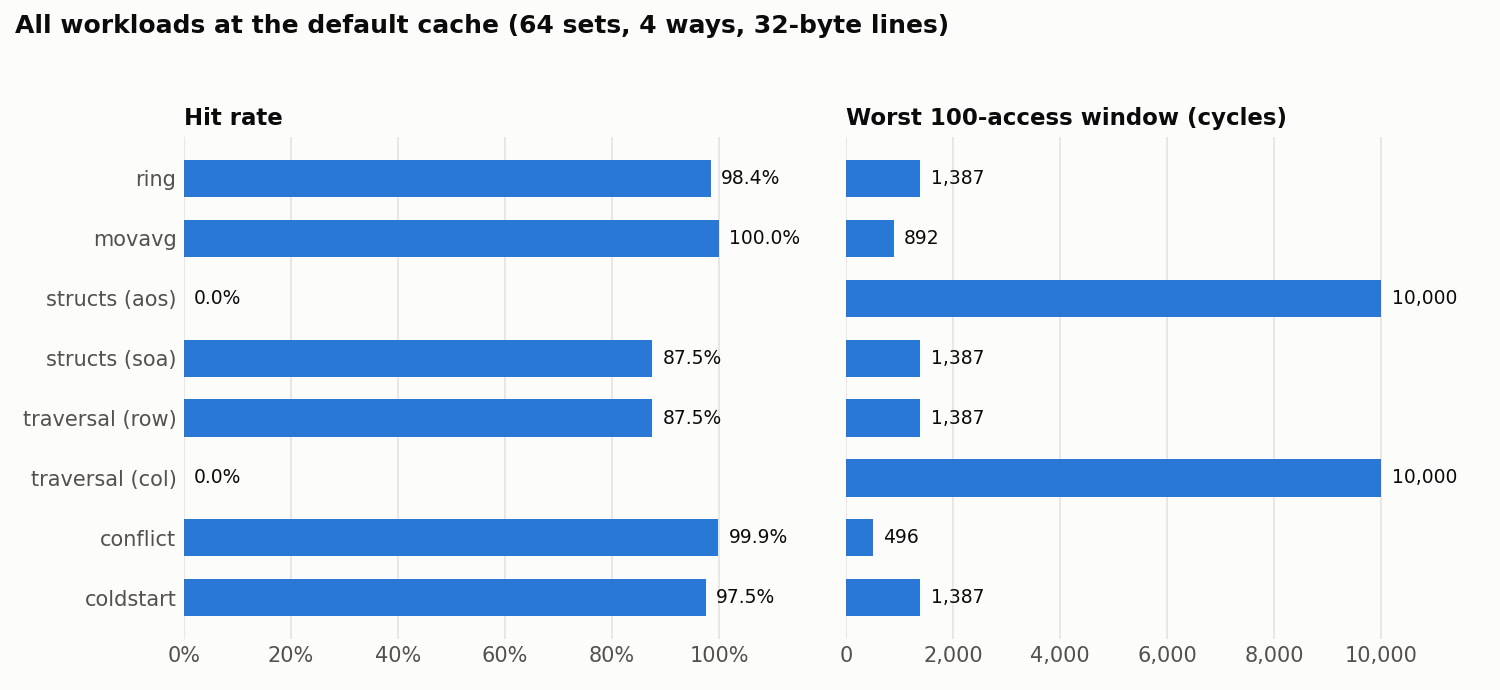

In [2]:
display(Image(filename="../results/plots/summary.png"))

### Were the hypotheses right?

Each line is computed from the CSV.

In [3]:
def row(workload, variant="", **where):
    q = df[(df.workload == workload) & (df.variant == variant)]
    for key, value in where.items():
        q = q[q[key] == value]
    return q.iloc[0]

d = dict(ways=4, line_size=32)
ring, avg = row("ring", **d), row("movavg", **d)
aos, soa = row("structs", "aos", **d), row("structs", "soa", **d)
by_row, by_col = row("traversal", "row", **d), row("traversal", "col", **d)
one_way, two_way = row("conflict", ways=1), row("conflict", ways=2)
cold = row("coldstart", **d)
steady_window = 100 * 1  # 100 hits at 1 cycle each

print(f"1 ring       hit rate {ring.hit_rate:.1%}; {ring.misses} misses = the {4096 // 32} cold lines, none after warm-up -> as predicted")
print(f"2 movavg     hit rate {avg.hit_rate:.2%}; {avg.misses} misses = the {256 // 32} lines of the window -> as predicted")
print(f"3 structs    aos {aos.misses} misses vs soa {soa.misses} ({aos.misses / soa.misses:.0f}x fewer) -> as predicted")
print(f"4 traversal  column {by_col.misses} misses vs row {by_row.misses} ({by_col.misses / by_row.misses:.0f}x more) -> as predicted, but see below")
print(f"5 conflict   1 way: {one_way.misses} of {one_way.accesses} accesses miss; 2 ways: {two_way.misses} -> as predicted")
print(f"6 coldstart  worst window {cold.worst_window_cycles} cycles vs {steady_window} in steady state "
      f"({cold.worst_window_cycles / steady_window:.0f}x) -> as predicted")

1 ring       hit rate 98.4%; 128 misses = the 128 cold lines, none after warm-up -> as predicted
2 movavg     hit rate 99.99%; 8 misses = the 8 lines of the window -> as predicted
3 structs    aos 1000 misses vs soa 125 (8x fewer) -> as predicted
4 traversal  column 4096 misses vs row 512 (8x more) -> as predicted, but see below
5 conflict   1 way: 4096 of 4096 accesses miss; 2 ways: 4 -> as predicted
6 coldstart  worst window 1387 cycles vs 100 in steady state (14x) -> as predicted


Every hypothesis held, but some details were not in the predictions.

### 1 and 2. Ring buffer and moving average

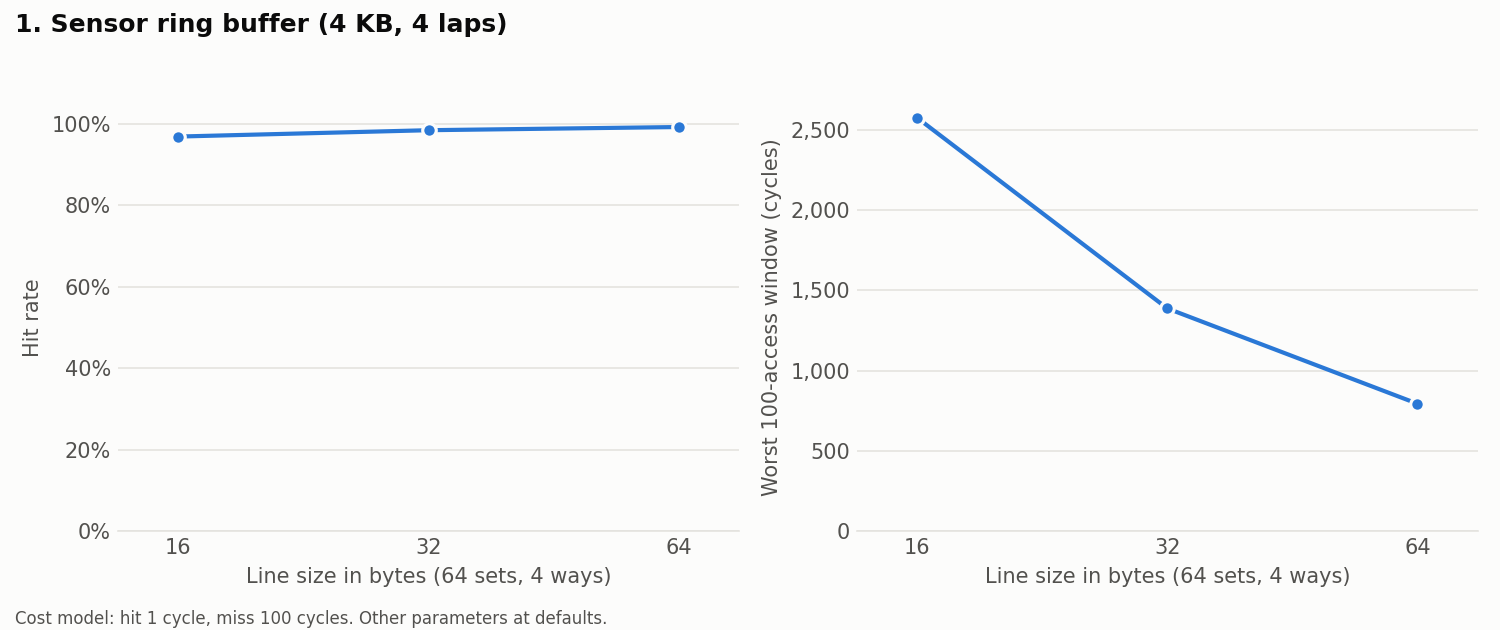

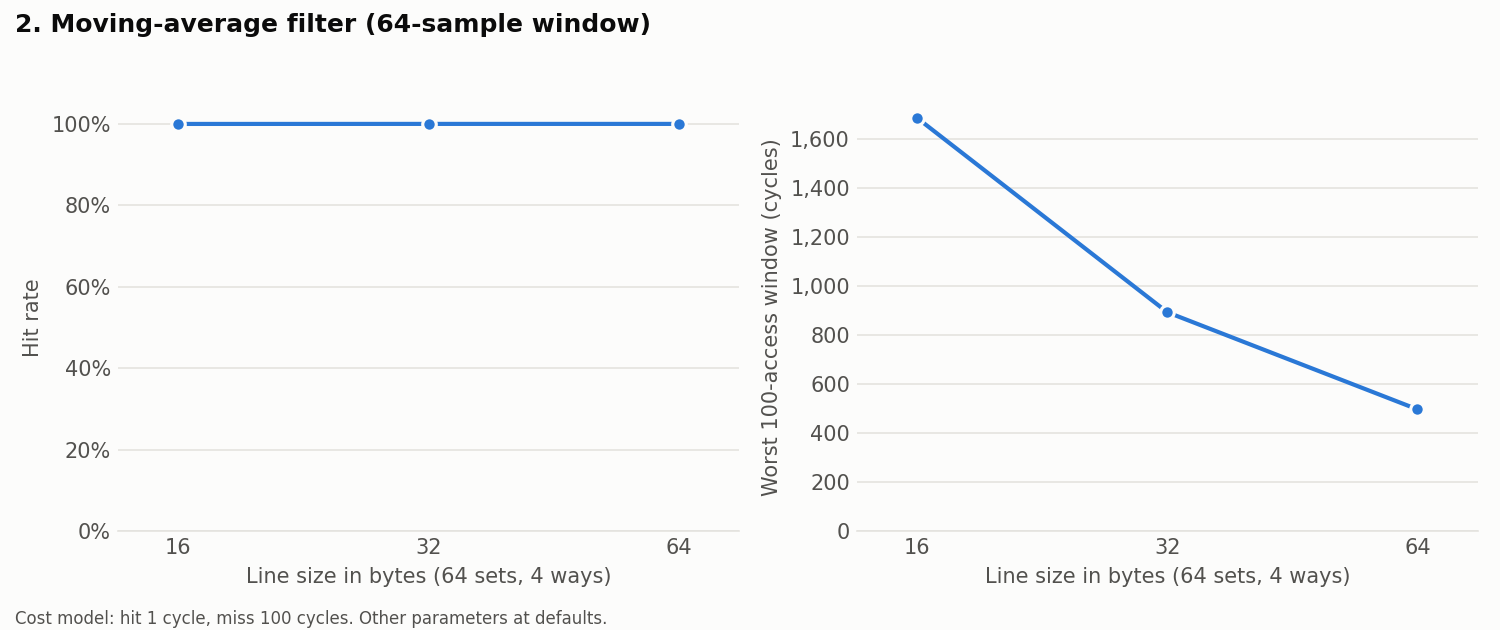

In [4]:
display(Image(filename="../results/plots/ring.png"))
display(Image(filename="../results/plots/movavg.png"))

Both are the predictable baseline: every miss is a cold miss on the first touch
of a line, then everything hits. Larger lines mean fewer cold misses, so the
worst window shrinks (ring: 2,575 cycles at 16-byte lines, 793 at 64). The
moving-average filter reads 99.99% hits but its worst window is still 892
cycles at the default, because the window has to be loaded once.

### 3. Array of structs vs struct of arrays

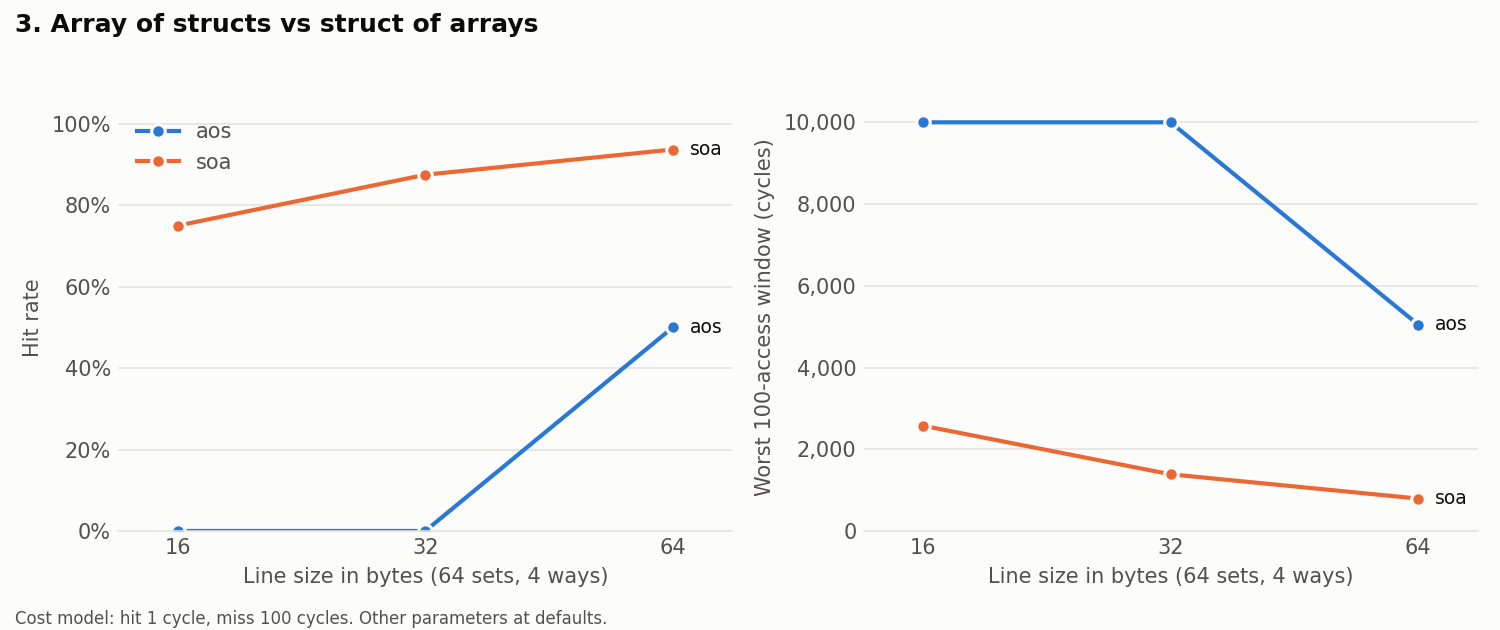

In [5]:
display(Image(filename="../results/plots/structs.png"))

Reading one 4-byte field of a 32-byte record touches a new line every time, so
the array of structs misses on every access (a 10,000-cycle window) at 16- and
32-byte lines. Packing the fields together uses all 8 fields in each line. Only
at 64-byte lines does the array of structs get 2 records per line (50% hits),
and that is still worse than the packed layout at 16-byte lines.

### 4. Row vs column traversal

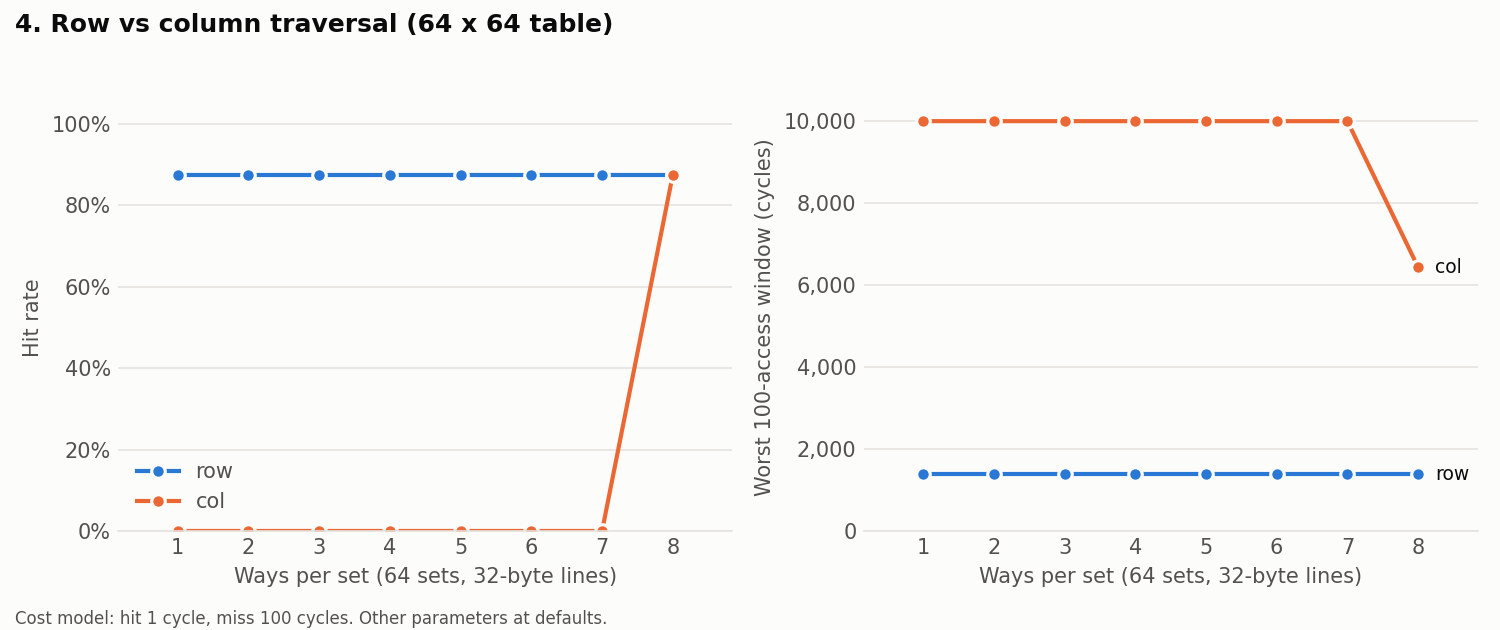

In [6]:
display(Image(filename="../results/plots/traversal.png"))

Column order misses on every access for 1 to 7 ways. A column step is 256 bytes,
so every access lands in one of only 8 of the 64 sets, and 64 rows need 8 ways to
stay resident. At 8 ways the column traversal suddenly recovers (87.5% hits),
but its worst window is still 6,436 cycles because the first columns have to be
loaded. Note this sweep also grows the cache from 2 KB to 16 KB, so it is a
capacity effect as much as an associativity effect.

### 5. Conflict thrash

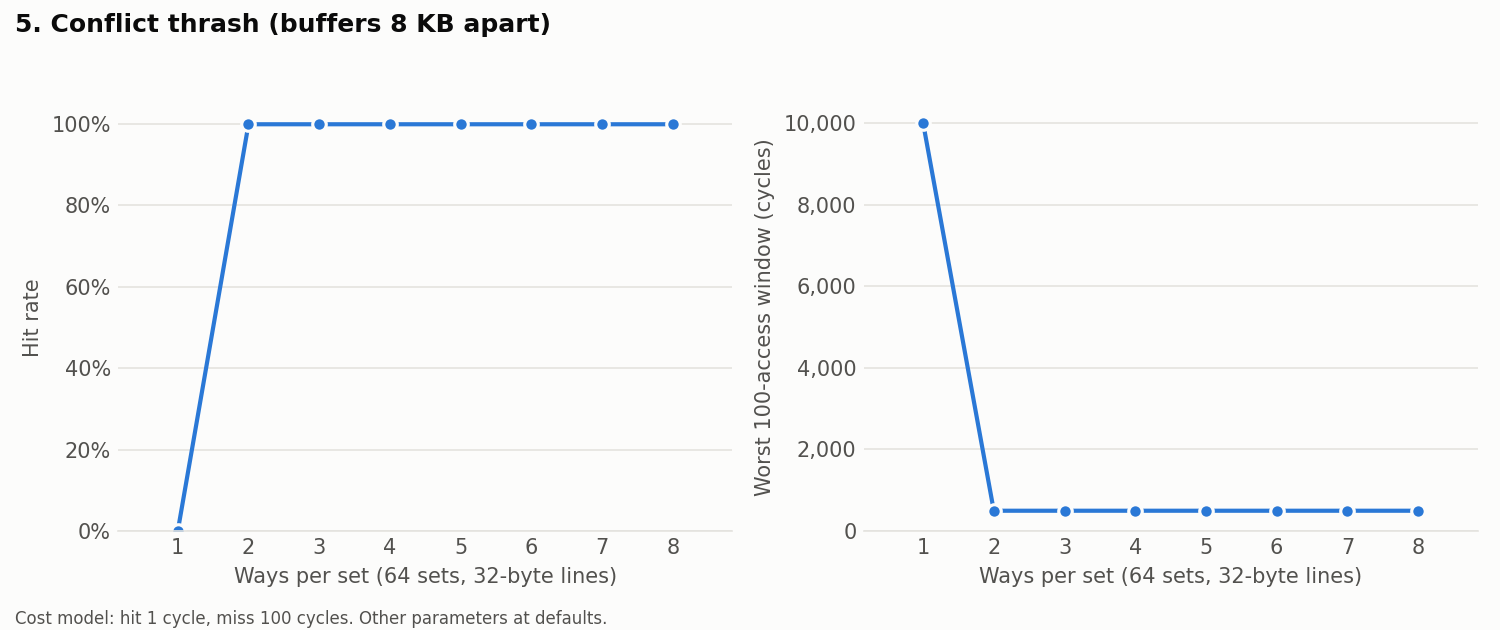

In [7]:
display(Image(filename="../results/plots/conflict.png"))

Two buffers that are a multiple of (sets x line size) apart map to the same sets.
With 1 way every access evicts the other buffer's line: 4,096 misses on a
128-byte working set. One extra way removes the problem completely. Nothing about
the data changed, only where the buffers sit.

### 6. Cold start vs steady state

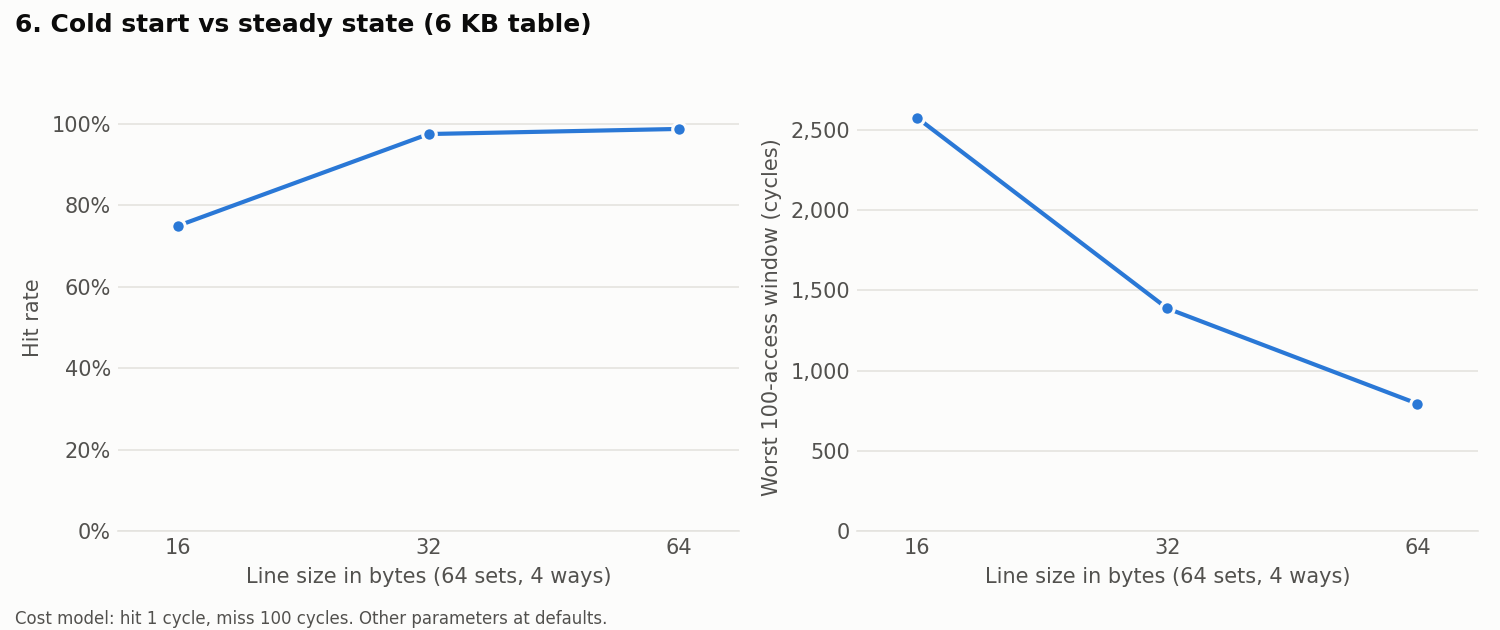

In [8]:
display(Image(filename="../results/plots/coldstart.png"))

At 32-byte lines the 6 KB table fits and only the first pass misses (192 misses
in 7,680 accesses). The worst window is 1,387 cycles against 100 once warm. At
16-byte lines the cache is 4 KB, smaller than the table, so a sequential scan
under LRU evicts each line before it is reused: every pass misses and the hit rate
sticks at 75%. Warm-up never finishes.

## Average vs worst case

The average hides the worst case. Cost per access over the whole run, against the
worst 100-access window divided by 100:

In [9]:
d = default.copy()
d["mean_cost"] = d.cost_mean
d["worst_window_per_access"] = d.worst_window_cycles / d.window
d["worst / mean"] = d.worst_window_per_access / d.mean_cost
print(d[["name", "mean_cost", "worst_window_per_access", "worst / mean"]].round(2).to_string(index=False))

           name  mean_cost  worst_window_per_access  worst / mean
           ring       2.55                    13.87          5.45
         movavg       1.01                     8.92          8.81
  structs (aos)     100.00                   100.00          1.00
  structs (soa)      13.38                    13.87          1.04
traversal (row)      13.38                    13.87          1.04
traversal (col)     100.00                   100.00          1.00
       conflict       1.10                     4.96          4.52
      coldstart       3.48                    13.87          3.99


The layouts that are bad everywhere (aos, column order) are slow but flat: worst
and average are about the same. The dangerous ones for a timing budget are ring,
movavg, conflict and coldstart, which look fast on average but have a worst
window 4 to 9 times the mean.

## Takeaway for deterministic code

What an engineer writing timing-critical code would change, based on these runs:

1. **Make the hot loop walk memory in order.** Struct of arrays and row-major
   order cut misses 8x here, with no change to the work done.
2. **Keep the working set inside the cache, with margin.** A 6 KB scan in a 4 KB
   cache never warms up. Size buffers against the smallest cache the code will run on.
3. **Control buffer placement.** Buffers a multiple of (sets x line size) apart
   collide. Align or pad them deliberately, or make sure the number of ways is at
   least the number of buffers that alias.
4. **Budget the first run, not the average.** The first pass was 14x the steady
   state. Either warm the cache before the critical section or bound the time from a cold cache.
5. **Judge by the worst window.** Several loops with a good average still have
   a worst window many times larger.

## Where the model stops being realistic

The simulator uses one cost for every hit and one for every miss. Real hardware
also has prefetching (which would hide many of the sequential misses above),
multiple cache levels, and bus contention from other masters, and this model
ignores all three. Also: the replacement policy is true LRU (many real caches
use cheaper approximations), there is one cache and no instruction fetches, the
writeback cost is 0 by default, and the cache parameters were changed one at a
time. The numbers show how layout changes hits and misses under this model. They
are not timing predictions for any real processor.